In [1]:
#!pip install seaborn

import sys
sys.path.append('/workspaces/ml-supervised-dev')

import pandas as pd
import numpy as np
from src.utils import carrega_dados, encoding_cols, get_x_y, save_model
import matplotlib.pyplot as plt # Para visualização e plots
import seaborn as sns # Para visualização e plots
%matplotlib inline
pd.set_option('display.max_rows', None) # Define o número máximo de linhas que o Pandas irá apresentar

from sklearn.cluster import KMeans # Classe do KMeans usada no sklearn
from sklearn.model_selection import train_test_split

In [3]:
iris = carrega_dados("flores_iris.csv", drop_cols=["Id"])
treino, validacao = train_test_split(iris, test_size=0.2)
#Salvando labels para comparação
species_validacao = validacao["Species"]
validacao = validacao.drop("Species", axis=1)
treino = treino.drop("Species", axis=1)

Reorganizando os dados...
Dados carregados


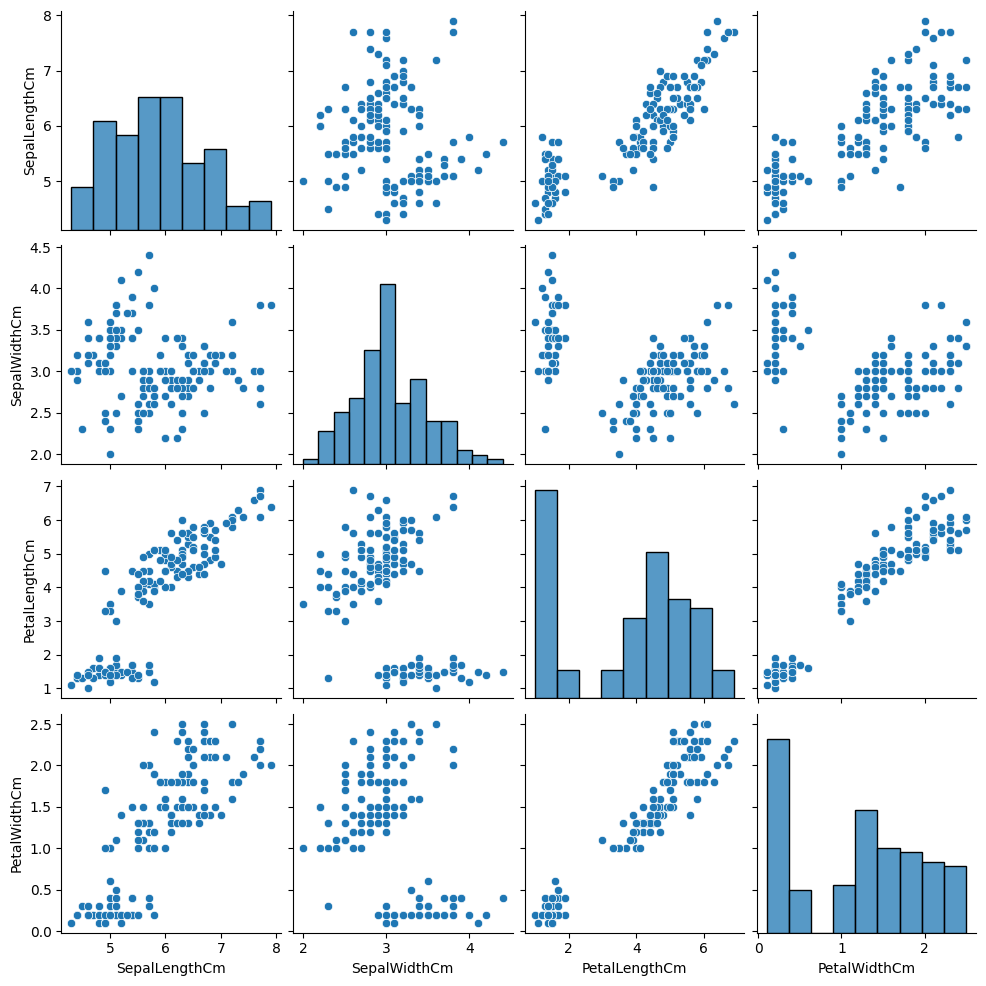

In [4]:
sns.pairplot(iris)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [6]:
kmeans.fit(treino)

KMeans(n_clusters=3, random_state=42)

In [7]:
kmeans.labels_

array([1, 0, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0,
       0, 2, 2, 0, 0, 1, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 0, 1, 2,
       0, 1, 1, 0, 0, 2, 1, 1, 0, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 0, 0,
       1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 0, 1, 0, 1, 2, 0, 1, 0, 1, 2, 0, 0,
       0, 2, 1, 0, 0, 2, 1, 2, 0, 0], dtype=int32)

In [8]:
kmeans.predict(validacao)

array([1, 1, 1, 1, 0, 2, 0, 2, 1, 0, 2, 2, 0, 2, 0, 2, 1, 0, 2, 0, 0, 2,
       0, 0, 1, 1, 1, 2, 1, 0], dtype=int32)

In [9]:
validacao["Grupo KMeans"] = kmeans.predict(validacao)
validacao["Especie real"] = species_validacao

In [10]:
validacao[validacao['Especie real']=='Iris-versicolor']

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Grupo KMeans,Especie real
82,5.8,2.7,3.9,1.2,0,Iris-versicolor
57,4.9,2.4,3.3,1.0,0,Iris-versicolor
81,5.5,2.4,3.7,1.0,0,Iris-versicolor
76,6.8,2.8,4.8,1.4,0,Iris-versicolor
71,6.1,2.8,4.0,1.3,0,Iris-versicolor
66,5.6,3.0,4.5,1.5,0,Iris-versicolor
75,6.6,3.0,4.4,1.4,0,Iris-versicolor
73,6.1,2.8,4.7,1.2,0,Iris-versicolor


In [11]:
validacao[validacao['Especie real']=='Iris-virginica']

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Grupo KMeans,Especie real
147,6.5,3.0,5.2,2.0,2,Iris-virginica
139,6.9,3.1,5.4,2.1,2,Iris-virginica
132,6.4,2.8,5.6,2.2,2,Iris-virginica
124,6.7,3.3,5.7,2.1,2,Iris-virginica
145,6.7,3.0,5.2,2.3,2,Iris-virginica
133,6.3,2.8,5.1,1.5,0,Iris-virginica
131,7.9,3.8,6.4,2.0,2,Iris-virginica
142,5.8,2.7,5.1,1.9,0,Iris-virginica
136,6.3,3.4,5.6,2.4,2,Iris-virginica
100,6.3,3.3,6.0,2.5,2,Iris-virginica


In [12]:
validacao[validacao['Especie real']=='Iris-setosa']

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Grupo KMeans,Especie real
43,5.0,3.5,1.6,0.6,1,Iris-setosa
29,4.7,3.2,1.6,0.2,1,Iris-setosa
23,5.1,3.3,1.7,0.5,1,Iris-setosa
46,5.1,3.8,1.6,0.2,1,Iris-setosa
40,5.0,3.5,1.3,0.3,1,Iris-setosa
16,5.4,3.9,1.3,0.4,1,Iris-setosa
49,5.0,3.3,1.4,0.2,1,Iris-setosa
17,5.1,3.5,1.4,0.3,1,Iris-setosa
41,4.5,2.3,1.3,0.3,1,Iris-setosa
8,4.4,2.9,1.4,0.2,1,Iris-setosa


In [13]:
# PCA para gerar o plot
from sklearn.decomposition import PCA

In [14]:
centroids = kmeans.cluster_centers_
pca = PCA(2)
x_pca = pca.fit_transform(treino)
centroids_pca = pca.transform(centroids)

/workspaces/ml-supervised-dev/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


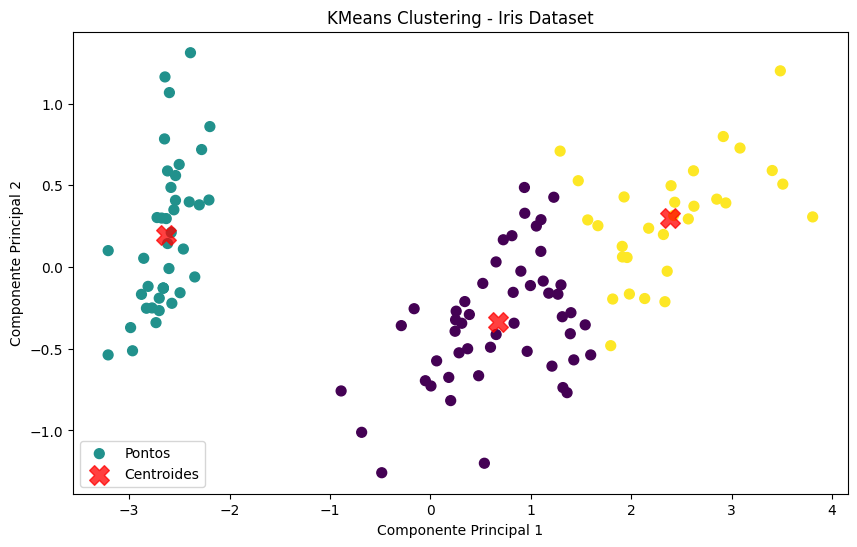

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=kmeans.labels_, s=50, cmap='viridis', label="Pontos")
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, alpha=0.75, marker='X', label="Centroides")
plt.title('KMeans Clustering - Iris Dataset')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()